# 09 · Nuclear elongation: round vs elongated nuclei in core, rim, distal tissue and meninges

Every segmented nucleus has an **eccentricity**: that of the ellipse with the same second moments as the
Cellpose nucleus mask, √(1 − (b/a)²) – 0 is a circle, 1 a line. It describes the *nucleus*, not the
cell's processes. Classes used here:

| class | eccentricity | long : short axis |
|---|---|---|
| round | < 0.6 | < 1.25 |
| intermediate | 0.6 – 0.85 | 1.25 – 1.9 |
| elongated | ≥ 0.85 | ≥ 1.9 |

Outlines are drawn from the label image (every QC-passed nucleus, Pu.1⁺ and Pu.1⁻; faint nuclei that
Cellpose filtered out have no outline). Compartments as in notebook 07: `core`, `rim`, `peri`, `deep`,
`distal` (lesion sections, parenchyma), `meninges`, control `GM` / `WM`.

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
%config InlineBackend.figure_format = 'jpeg'   # image-heavy notebooks: keep files small
plt.rcParams["figure.dpi"] = 80
from lesionseg import report as R
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
RUN_DIR = "outputs/sdata"
runs = R.load_runs(RUN_DIR)
print("scenes:", [r.name for r in runs])

from lesionseg import expression as E, morphology as M
df = E.expression_table(runs)
cells_by_scene = {r.name: r.cells for r in runs}
# windows: surface meninges only (flaps / roots deeper than 80 µm are often sparse or artefact-ridden)
comp_by_scene = {r.name: M.window_compartments(r.cells, E.compartment(r.cells)) for r in runs}
SIZE = 120  # µm per zoom-in

scenes: ['CML_1 scene 0', 'CML_2_rescan scene 0', 'CML_metal scene 0', 'CML_metal scene 1']


## Side by side: one typical window per compartment (same scale, 120 µm)

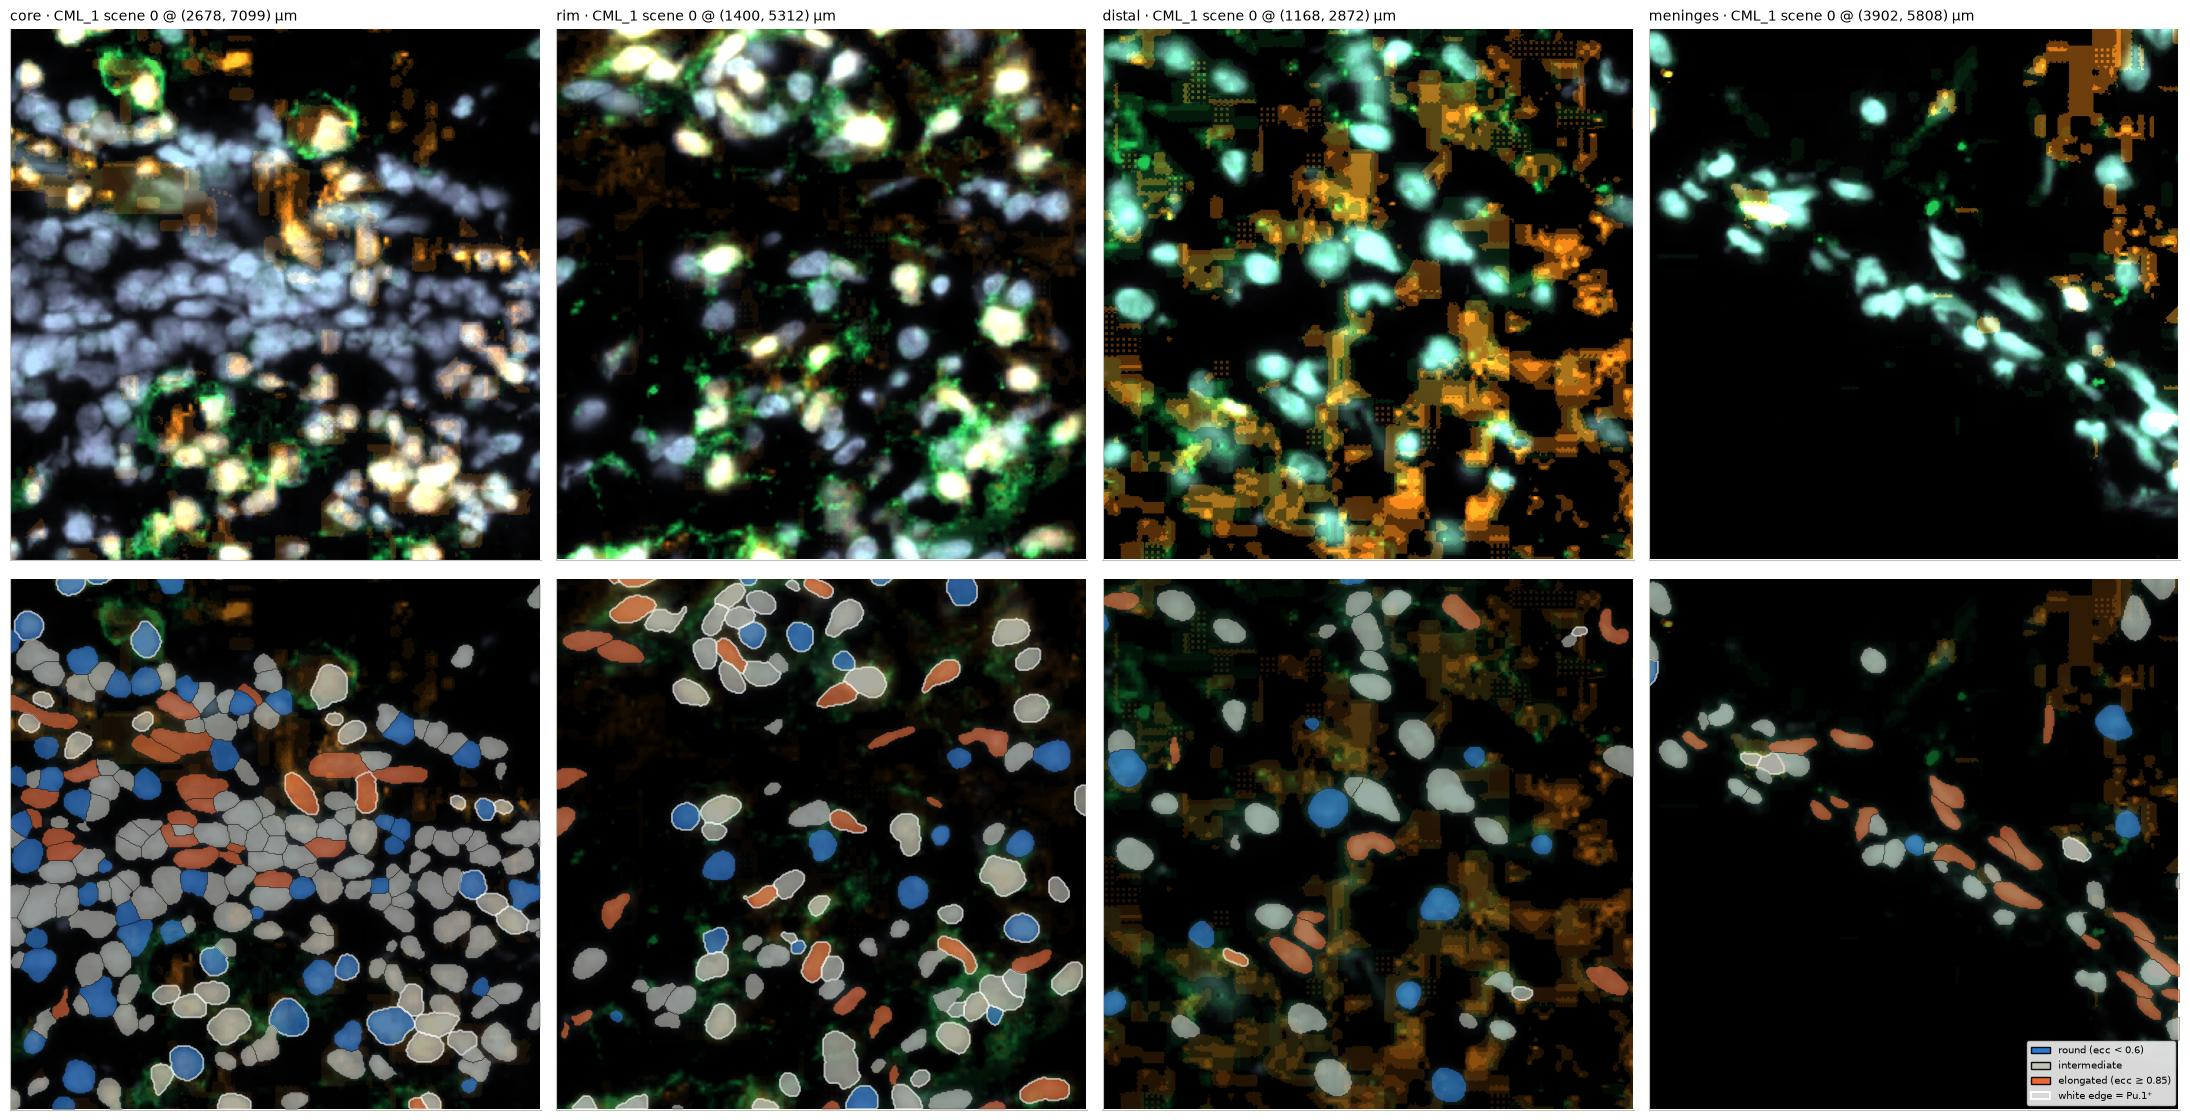

In [2]:
order = ["core", "rim", "distal", "meninges"]
fig, axes = plt.subplots(2, 4, figsize=(22, 11.5))
for j, comp in enumerate(order):
    for r in runs:
        w = M.representative_windows(r.cells, comp_by_scene[r.name], comp, size_um=SIZE, n=1,
                                     min_frac=0.5 if comp == "meninges" else 0.8)
        if w:
            break
    x, y = w[0]
    M.plot_nuclei(axes[0, j], r, r.cells, x, y, SIZE, raw=True)
    M.plot_nuclei(axes[1, j], r, r.cells, x, y, SIZE)
    axes[0, j].set_title(f"{comp} · {r.name} @ ({x:.0f}, {y:.0f}) µm", loc="left", fontsize=10)
M.class_legend(axes[1, -1])
plt.tight_layout(); plt.show()

## How common are elongated and round nuclei per compartment?

Share of each class per slide × section (median over slide × sections), for all nuclei, Pu.1⁺ and Pu.1⁻.

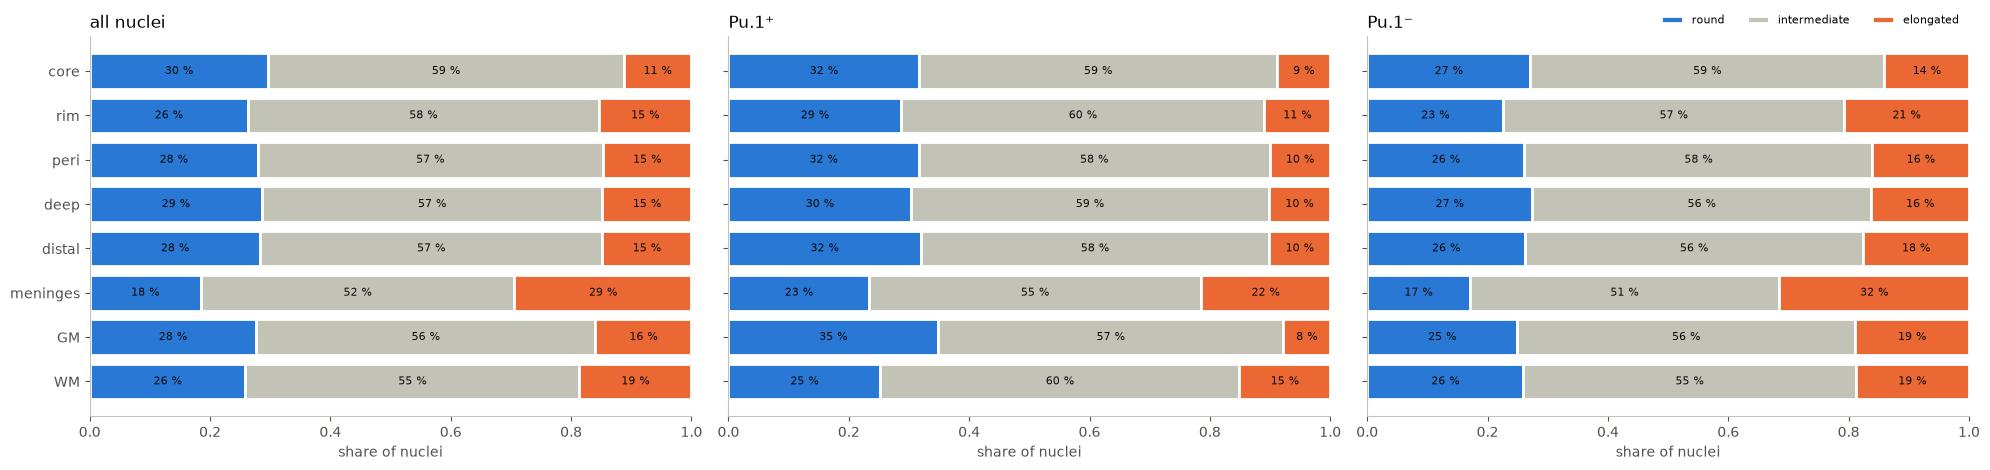

**all nuclei**

ecc_class,round,intermediate,elongated
compartment,,,
core,29.6,59.1,11.3
rim,26.3,58.3,15.4
peri,27.9,57.4,14.7
deep,28.6,56.6,14.8
distal,28.3,56.8,14.9
meninges,18.4,52.2,29.4
GM,27.6,56.4,16.0
WM,25.9,55.5,18.7


**Pu.1⁺**

ecc_class,round,intermediate,elongated
compartment,,,
core,31.7,59.5,8.8
rim,28.7,60.4,10.9
peri,31.6,58.3,10.1
deep,30.3,59.4,10.2
distal,31.9,57.9,10.2
meninges,23.4,55.1,21.5
GM,34.8,57.4,7.8
WM,25.2,59.6,15.1


**Pu.1⁻**

ecc_class,round,intermediate,elongated
compartment,,,
core,27.0,58.9,14.1
rim,22.6,56.6,20.8
peri,26.1,57.9,16.0
deep,27.4,56.4,16.3
distal,26.2,56.2,17.6
meninges,17.0,51.4,31.5
GM,24.9,56.2,18.9
WM,25.9,55.2,18.8


In [3]:
comps = ["core", "rim", "peri", "deep", "distal", "meninges", "GM", "WM"]
fig, axes = plt.subplots(1, 3, figsize=(20, 4.8), sharey=True)
tabs = {}
for ax, (label, which) in zip(axes, (("all nuclei", "all"), ("Pu.1⁺", "pos"), ("Pu.1⁻", "neg"))):
    sh = M.class_shares(df, which).groupby("compartment", observed=True)[M.CLASS_ORDER].median().reindex(comps)
    sh = sh.div(sh.sum(axis=1), axis=0)
    tabs[label] = sh
    left = np.zeros(len(sh))
    for k in M.CLASS_ORDER:
        ax.barh(sh.index, sh[k], left=left, color=M.CLASS_COLORS[k], edgecolor="white", linewidth=2, label=k)
        for i, (l, v) in enumerate(zip(left, sh[k])):
            if v > 0.06:
                ax.text(l + v / 2, i, f"{100 * v:.0f} %", ha="center", va="center", fontsize=8, color="#0b0b0b")
        left += sh[k].to_numpy()
    ax.set_xlim(0, 1); ax.set_title(label, loc="left"); ax.set_xlabel("share of nuclei")
axes[0].invert_yaxis(); axes[-1].legend(fontsize=8, frameon=False, ncol=3, loc="lower right", bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()
for label, sh in tabs.items():
    display(Markdown(f"**{label}**")); display((100 * sh).round(1))

### Eccentricity distributions (all nuclei, pooled – descriptive)

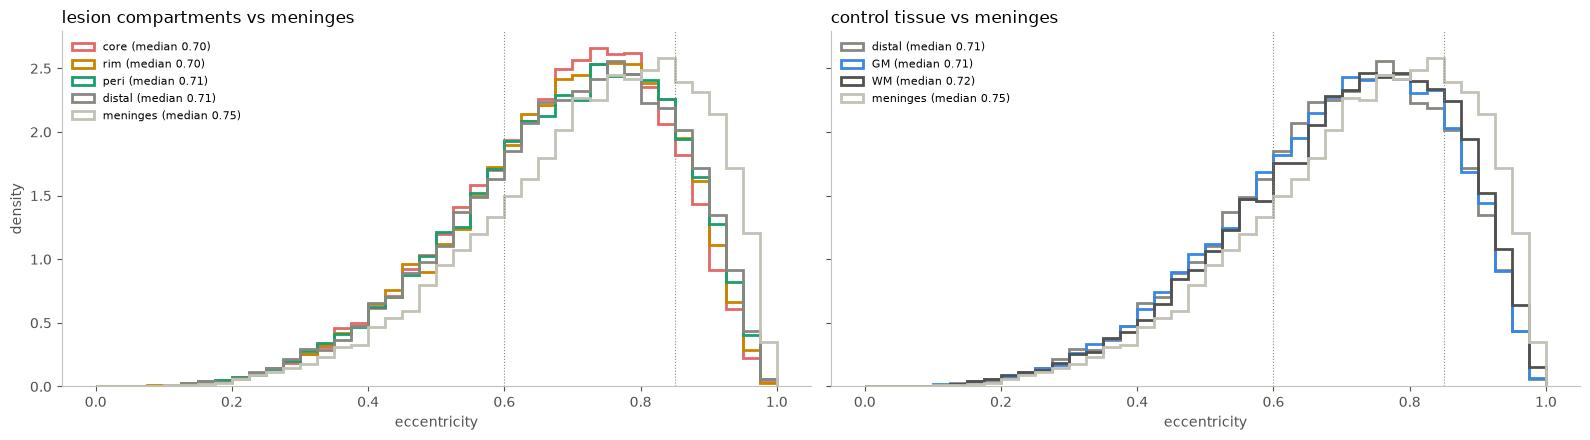

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), sharey=True)
bins = np.linspace(0, 1, 41)
for ax, group in ((axes[0], ["core", "rim", "peri", "distal", "meninges"]), (axes[1], ["distal", "GM", "WM", "meninges"])):
    for c in group:
        v = df.loc[df.compartment == c, "eccentricity"].dropna()
        ax.hist(v, bins=bins, histtype="step", lw=2, density=True, color=E.COLORS[c], label=f"{c} (median {v.median():.2f})")
    for t in (M.ROUND_MAX, M.ELONG_MIN):
        ax.axvline(t, color="#898781", lw=0.8, ls=":")
    ax.set_xlabel("eccentricity"); ax.legend(fontsize=8, frameon=False, loc="upper left")
axes[0].set_ylabel("density"); axes[0].set_title("lesion compartments vs meninges", loc="left"); axes[1].set_title("control tissue vs meninges", loc="left")
plt.tight_layout(); plt.show()

### Elongated share vs the same section's distal tissue (paired; one line per section)

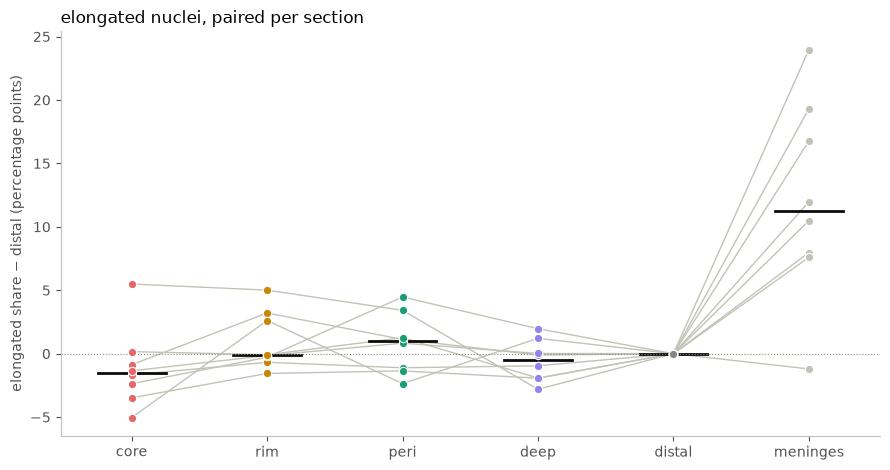

compartment,core,rim,peri,deep,distal,meninges
section,,,,,,
CFA_L2_C,NaN,NaN,NaN,NaN,NaN,NaN
CFA_L2_L,NaN,NaN,NaN,NaN,NaN,NaN
CFA_L2_T,NaN,NaN,NaN,NaN,NaN,NaN
OS1_2_,NaN,NaN,NaN,NaN,NaN,NaN
OS1_2_C,NaN,NaN,NaN,NaN,NaN,NaN
OS1_2_L,NaN,NaN,NaN,NaN,NaN,NaN
P2_3_C,-2.4,-0.3,4.5,2.0,0.0,16.8
P2_3_L,-1.7,-0.7,-1.1,-1.0,0.0,8.0
P2_3_T,-0.9,3.2,1.1,-0.1,0.0,24.0


In [5]:
sh = M.class_shares(df, "all")
ref = sh[sh.compartment == "distal"].set_index(["scene", "section"])["elongated"]
sh["d_elongated"] = sh["elongated"] - sh.set_index(["scene", "section"]).index.map(ref).to_numpy()
per = sh.groupby(["section", "compartment"], observed=True)["d_elongated"].mean().unstack("compartment")
cols = ["core", "rim", "peri", "deep", "distal", "meninges"]
per = per.reindex(columns=cols)
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(cols))
for _, row in per.iterrows():
    ax.plot(x, 100 * row.to_numpy(float), color="#c3c2b7", lw=1)
for i, c in enumerate(cols):
    v = 100 * per[c].dropna()
    ax.scatter(np.full(len(v), i), v, s=36, color=E.COLORS[c], edgecolors="white", linewidths=0.8, zorder=3)
    ax.plot([i - 0.25, i + 0.25], [v.median()] * 2, color="#0b0b0b", lw=2)
ax.axhline(0, color="#898781", lw=0.8, ls=":"); ax.set_xticks(x, cols)
ax.set_ylabel("elongated share − distal (percentage points)"); ax.set_title("elongated nuclei, paired per section", loc="left")
plt.tight_layout(); plt.show()
display((100 * per).round(1))

## Representative zoom-ins per compartment

Three typical windows per compartment, from different slides where possible: the compartment covers most
of the window (≥ 80 %, meninges ≥ 50 % since the band is thin), the window holds ≥ 40 nuclei, and its
median eccentricity is close to the compartment's own median (not the most extreme spots). Meninges
windows come from the surface meninges only, not from thin flaps or roots. Top = image, bottom = every nucleus filled by class; white edge = Pu.1⁺.

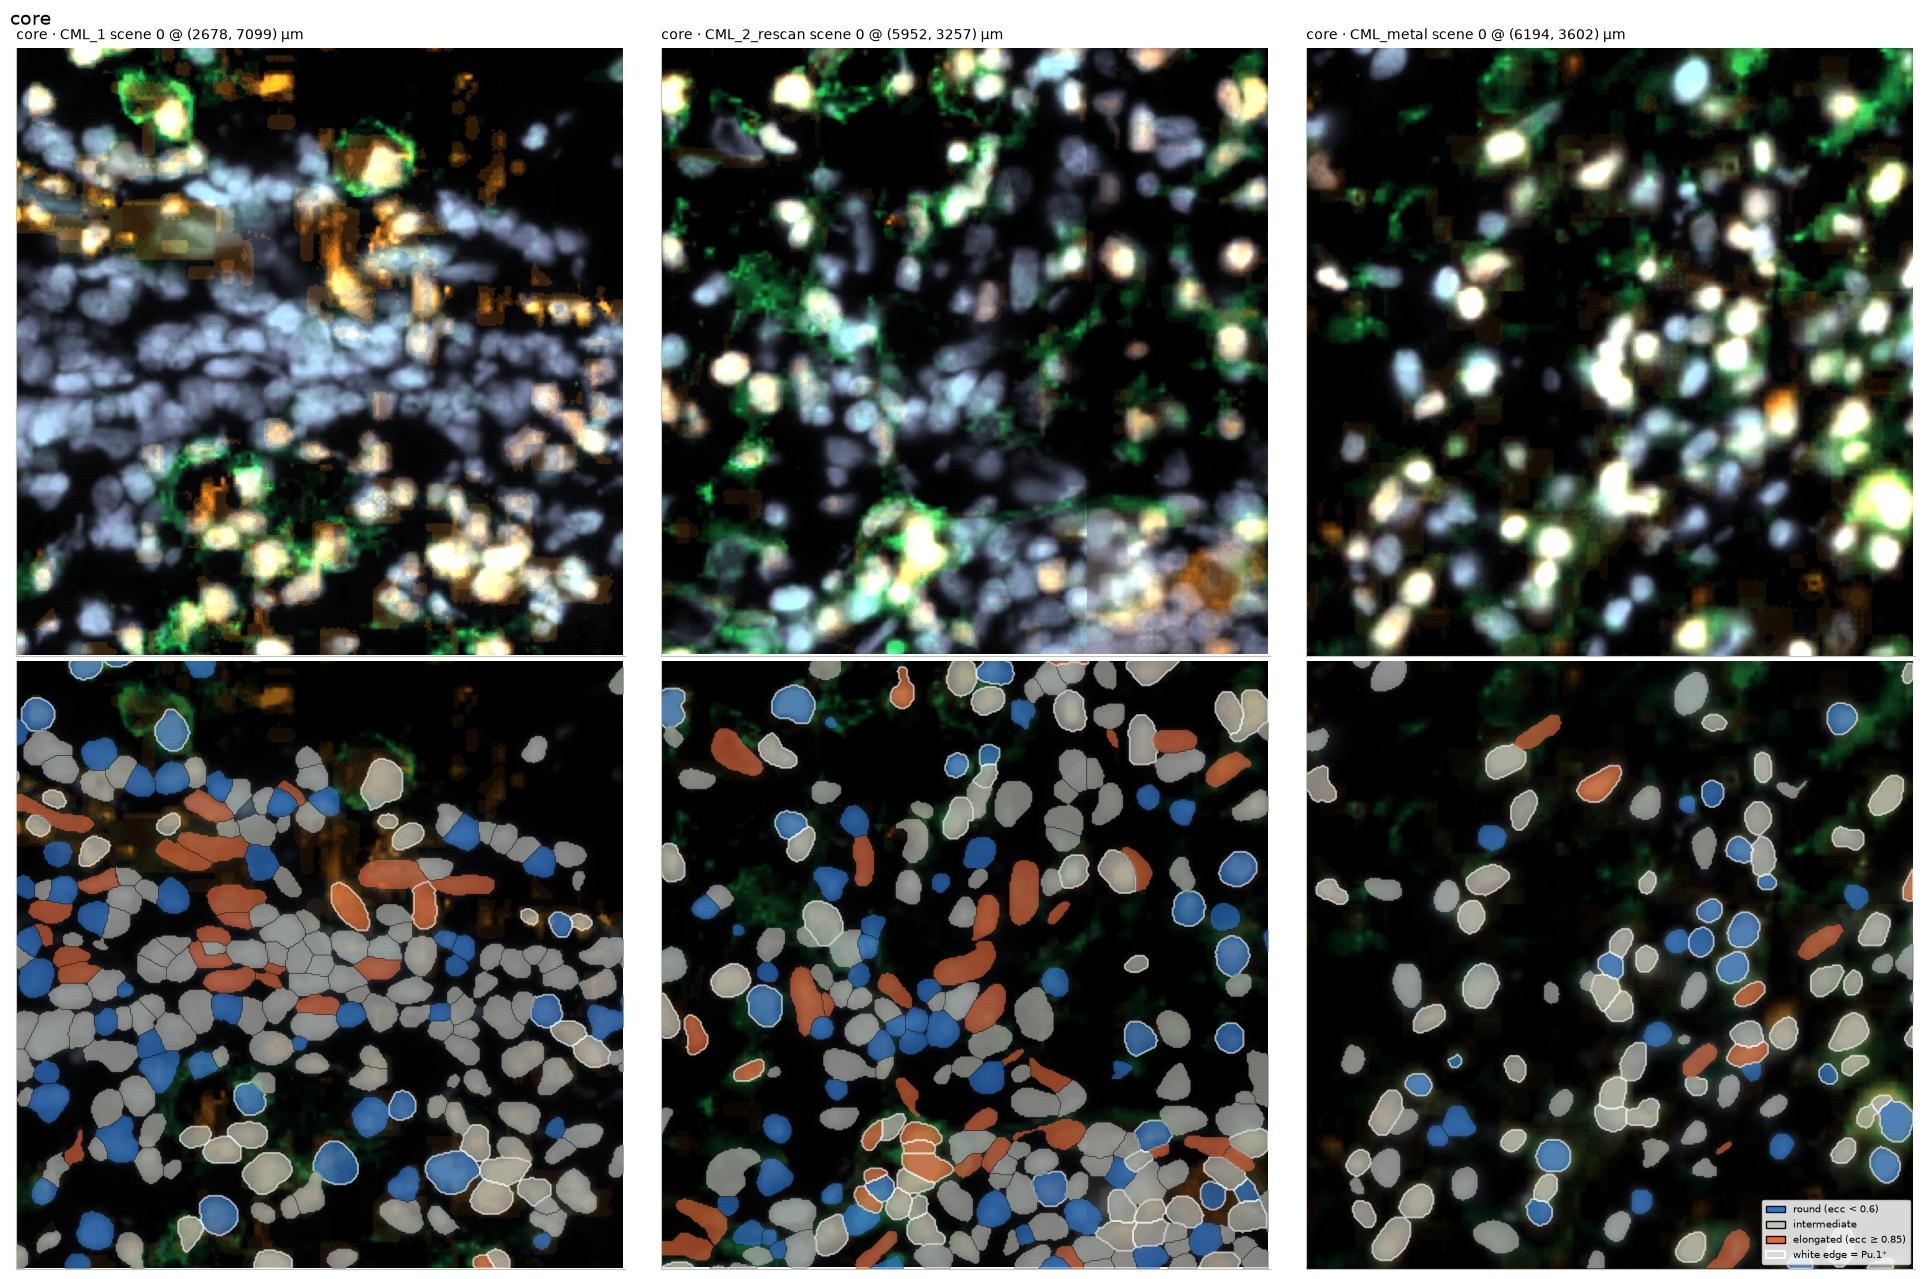

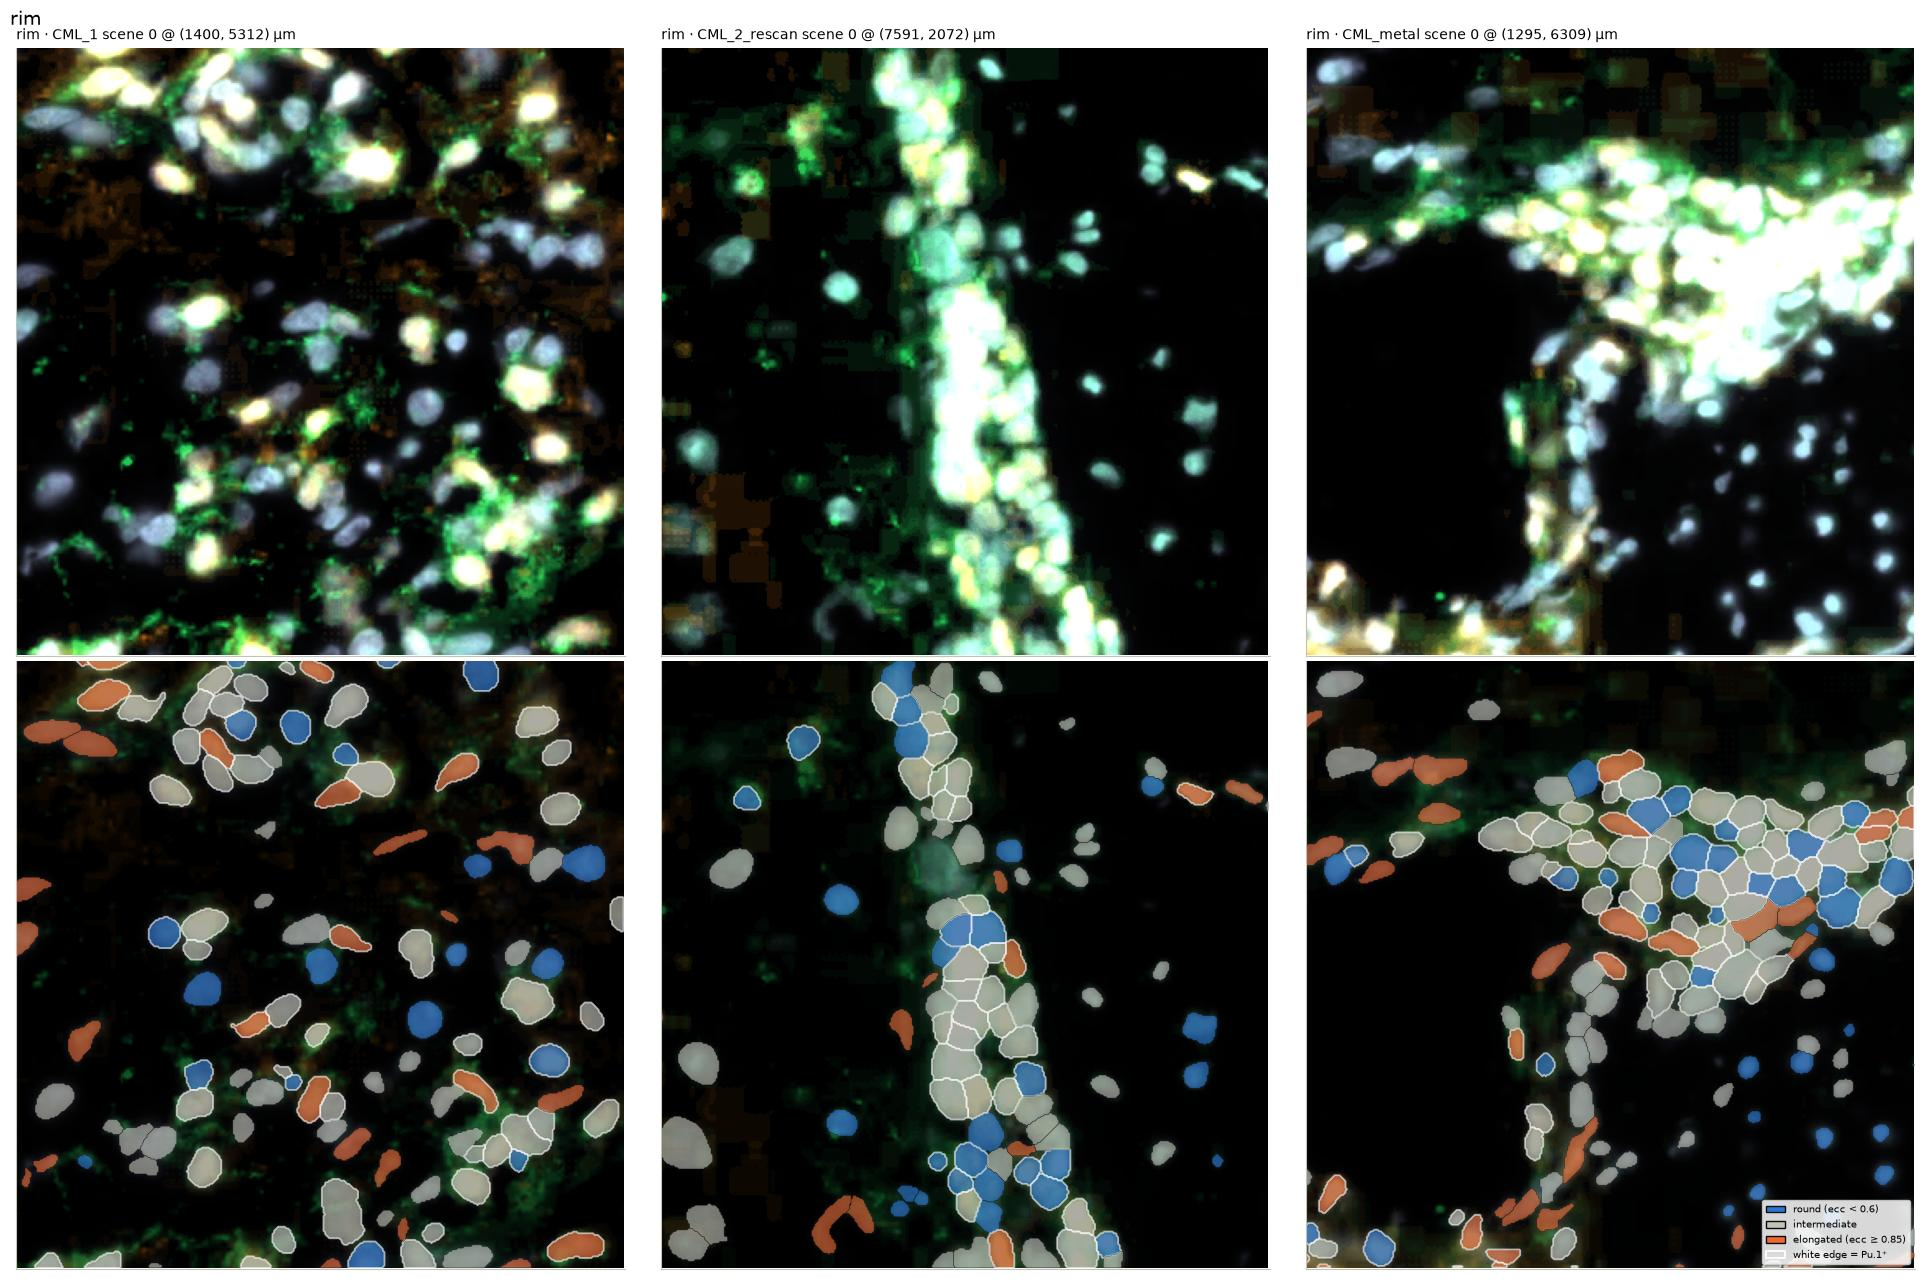

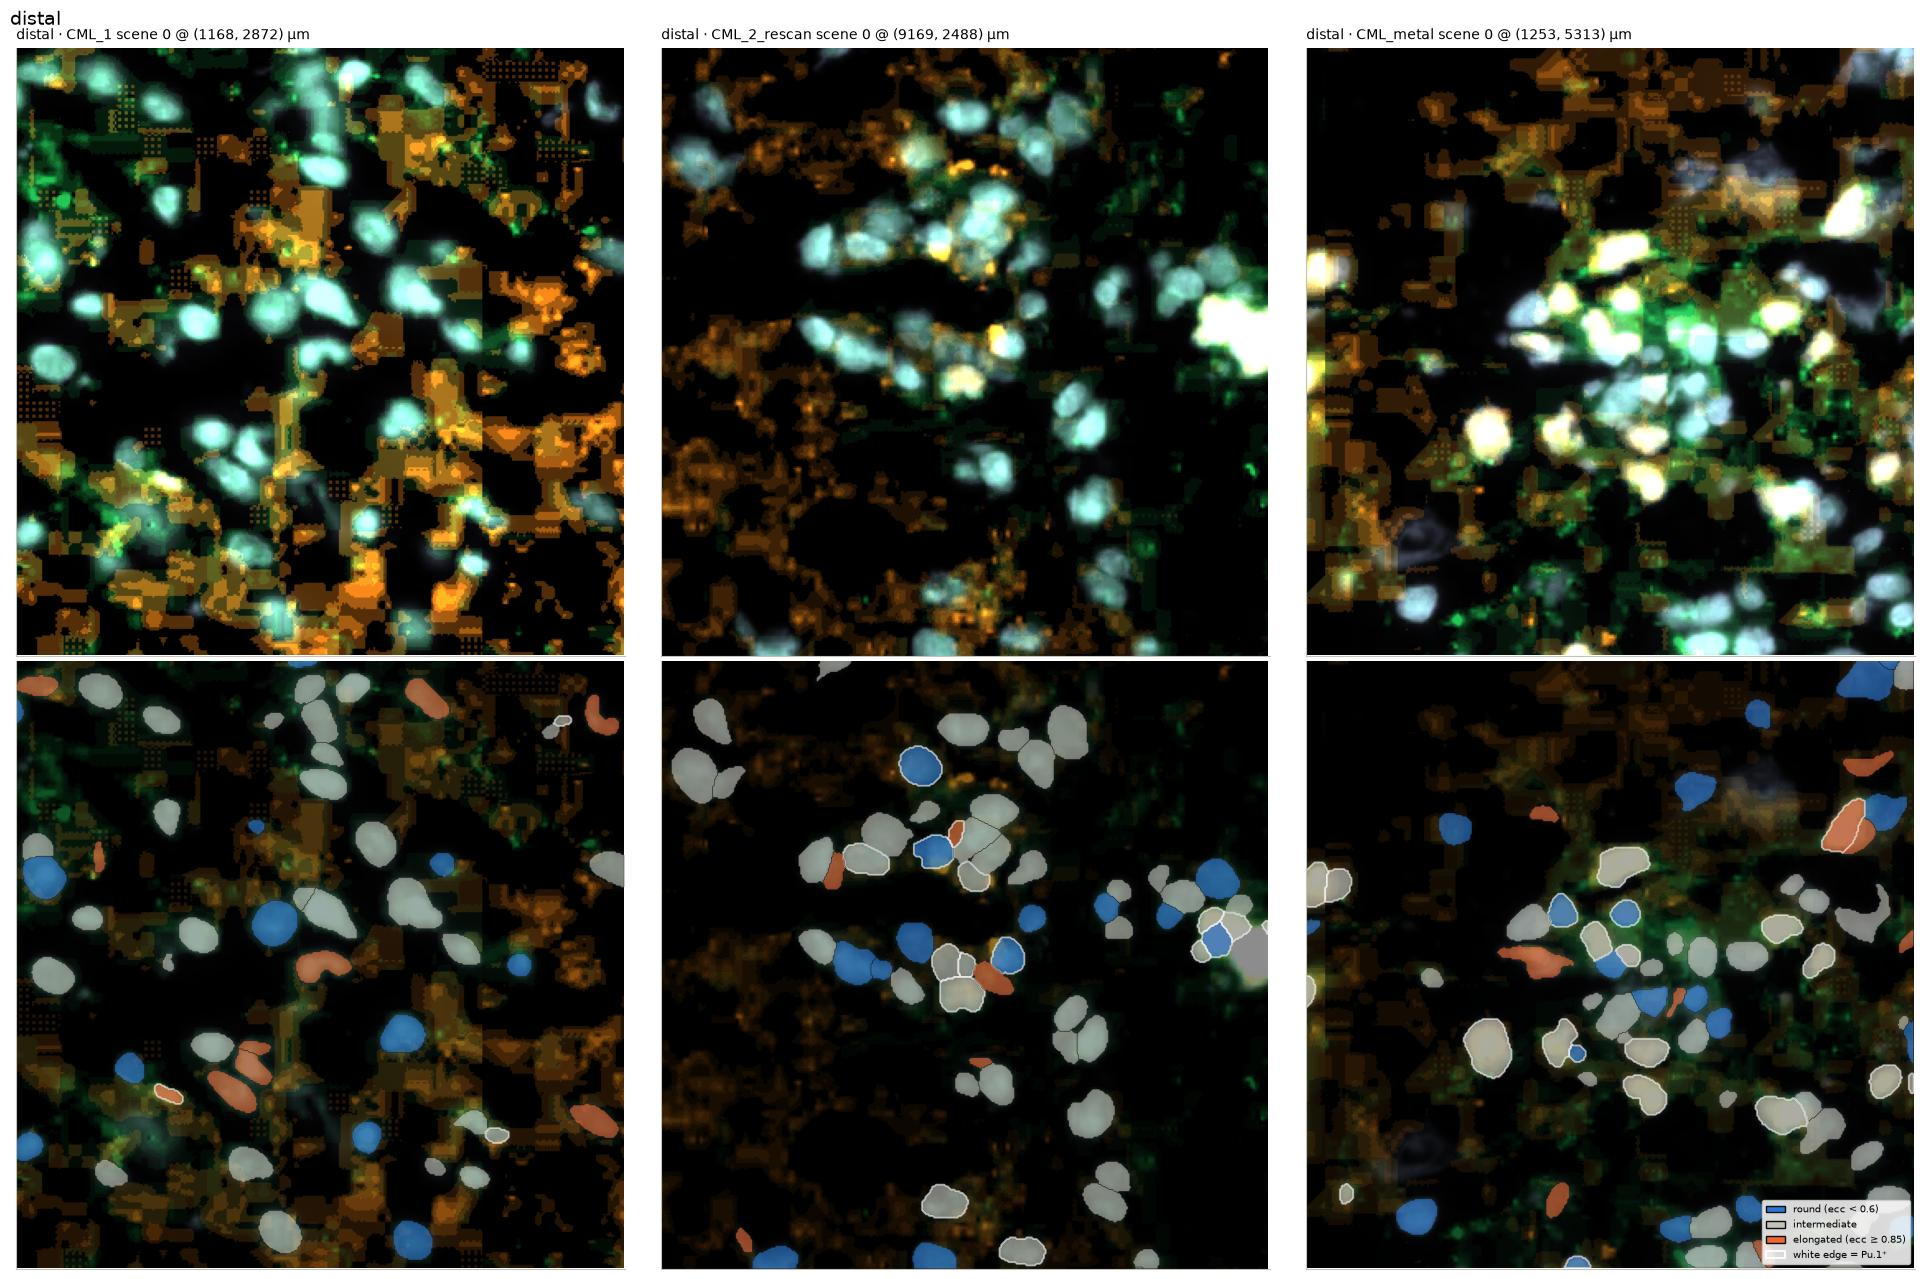

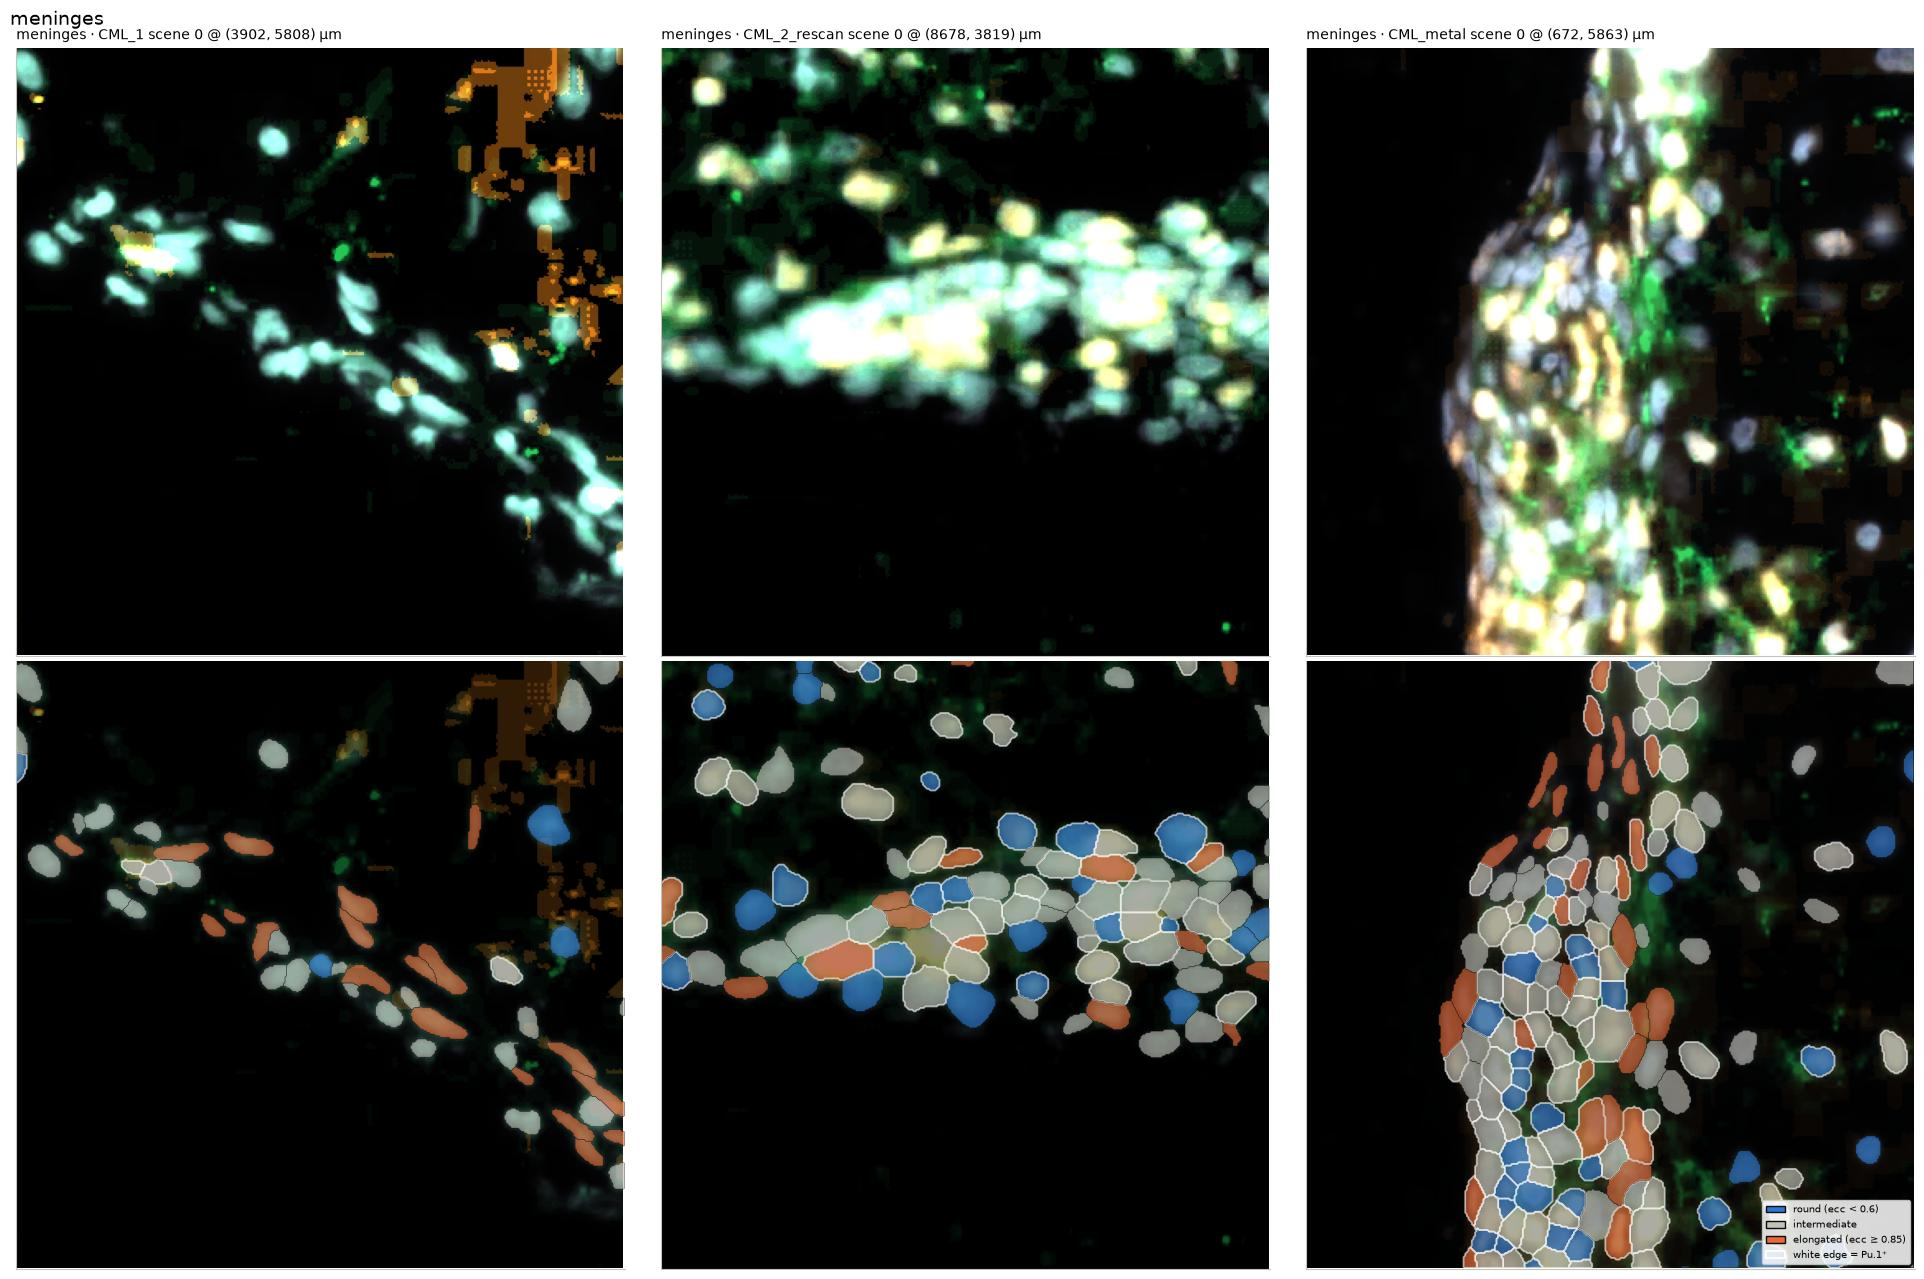

In [6]:
for comp in ["core", "rim", "distal", "meninges"]:
    picks = []
    for r in runs:
        for w in M.representative_windows(r.cells, comp_by_scene[r.name], comp, size_um=SIZE, n=1,
                                          min_frac=0.5 if comp == "meninges" else 0.8):
            picks.append((r, w))
    picks = picks[:3]
    fig, axes = plt.subplots(2, len(picks), figsize=(6.5 * len(picks), 13), squeeze=False)
    for j, (r, (x, y)) in enumerate(picks):
        M.plot_nuclei(axes[0, j], r, r.cells, x, y, SIZE, raw=True)
        M.plot_nuclei(axes[1, j], r, r.cells, x, y, SIZE)
        axes[0, j].set_title(f"{comp} · {r.name} @ ({x:.0f}, {y:.0f}) µm", loc="left", fontsize=10)
    M.class_legend(axes[1, -1])
    fig.suptitle(comp, x=0.01, ha="left", fontsize=14)
    plt.tight_layout(); plt.show()

## Reading

* The meninges carry the most elongated nuclei – flattened meningeal / pial cells lying along the surface
  (visible in the zoom-ins), in Pu.1⁺ and Pu.1⁻ cells alike.
* Lesion compartments differ little from distal tissue in nuclear shape; what changes near lesions is
  Pu.1 / Iba1 level and nuclear size (notebooks 07–08).
* Eccentricity says nothing about orientation; a next step could measure whether elongated nuclei lie
  parallel to the surface (meninges) or along fibre tracts / vessels (white matter, perivascular cuffs).